In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import pandas as pd
APOGEE = 135020744 # <-- remplacer par votre numéro d'Apogée
assert isinstance(APOGEE, int) and 1 <= APOGEE <= 999_999_999


np.random.seed(APOGEE) # fix the randomness
tf.random.set_seed(APOGEE)

In [2]:
import tensorflow as tf
print('La Version de tensorflow installée est : ',tf.__version__)


La Version de tensorflow installée est :  2.19.0


L’utilisation de numéro d’Apogée comme seed a deux avantages:

C’est un entier unique et stable pour chaque personne.

Ça garantit que les expériences sont identifiables et consistantes avec ce numéro.

Sans seed, chaque exécution pourrait donner des résultats légèrement différents, ce qui complique la comparaison d’algorithmes ou l’évaluation de performances.


In [3]:
def e():
  return np.random.normal(0, 0.1**2, 64)

In [4]:
def generate_gesture(gesture_type, num_samples=64, sample_rate=50):
  """
  Génère un geste synthétique.
  Args:
  gesture_type : int (0=repos, 1=cercle, 2=ligne, 3=zigzag)
  num_samples : nombre d'échantillons temporels
  sample_rate : fréquence d'échantillonnage (Hz)
  Returns:
  data : array de forme (num_samples, 3)
  label : int (classe du geste)
  """
  # Axe temporel
  t = np.linspace(0, num_samples/sample_rate, num=num_samples)
  # Niveau de bruit
  noise = 0.1

# Initialisation des axes X, Y, Z
  x = e()*noise
  y = e()*noise
  z = e()*noise + 1



  if gesture_type == 0:
    pass
  elif gesture_type == 1:
    A = np.random.uniform(0.8, 1.2)
    f = np.random.uniform(0.5, 2)
    x = A*np.cos(2*np.pi*f*t) + x
    y = A*np.sin(2*np.pi*f*t) + y
  elif gesture_type == 2:
    a = np.random.uniform(-2, 2)
    b = np.random.uniform(-1, 1)
    x = a*t + b + x
  elif gesture_type == 3:
    f = np.random.uniform(2.5)
    x =np.sign(np.cos(2*np.pi*f*t)) + x

  else:
    raise ValueError("Type de geste invalide")

  data = (x,y,z) # ( (1,64) (1,64) ) ---> (64 , 3)

  df = pd.DataFrame()
  df[0] = x
  df[1] = y
  df[2] = z
  data = df.to_numpy()
  label = gesture_type
  return data, label

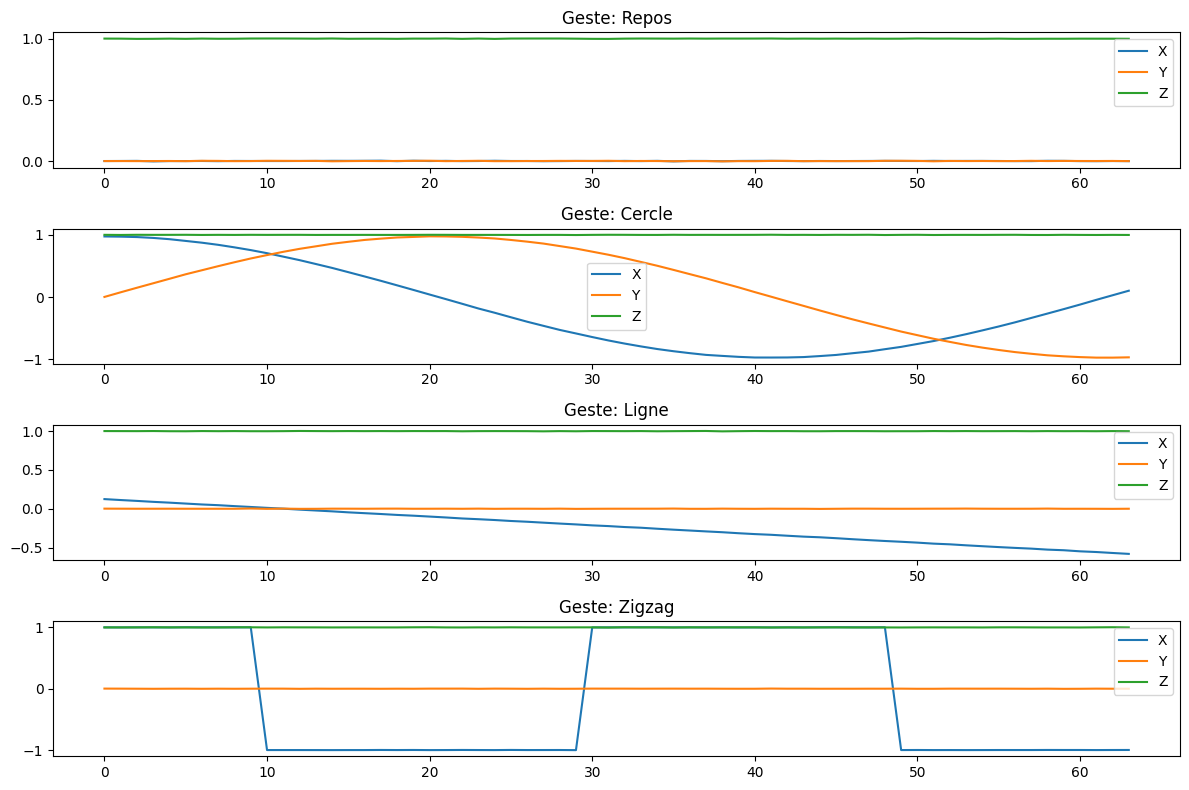

In [5]:
gesture_names = ["Repos", "Cercle", "Ligne", "Zigzag"]

plt.figure(figsize=(12, 8))
for i in range(4):
    data, label = generate_gesture(i)
    plt.subplot(4, 1, i+1)
    plt.plot(data[:,0], label="X")
    plt.plot(data[:,1], label="Y")
    plt.plot(data[:,2], label="Z")
    plt.title(f"Geste: {gesture_names[i]}")
    plt.legend()
plt.tight_layout()
plt.show()

Caractéristiques temporelles observables :

Repos (0) : les signaux restent presque constants avec juste un léger bruit.

Cercle (1) : les signaux X et Y oscillent de manière sinusoïdale avec un déphasage, formant un motif circulaire en XY. Z reste presque constant.

Ligne (2) : X croît linéairement (tendance monotone), Y reste faible, Z presque constant.

Zigzag (3) : X alterne rapidement entre des valeurs positives et négatives (motif carré), Y reste faible, Z constant.

In [6]:
def create_dataset(samples_per_class=300):
  """
  Crée un dataset synthétique pour 4 classes de gestes.
  Returns:
  X : array de forme (N, 64, 3) - données normalisées
  y : array de forme (N,) - labels
  """
  X_list = []
  y_list = []
  # Génération des données pour chaque classe
  for gesture_type in range(4):
    for _ in range(samples_per_class):
      data, label = generate_gesture(gesture_type)
      X_list.append(data)
      y_list.append(label)
  # Conversion en tableaux NumPy
  X = np.array(X_list)
  y = np.array(y_list)
  # Normalisation Z-score (par échantillon et par axe)
  X_normalized = X
  for i in range(samples_per_class):
    for axis in range(3):

      mean = np.mean(X_normalized[:, :, axis])
      std = np.std(X_normalized[:, :, axis])
      if std != 0:

        X_normalized[i, :, axis] = (X_normalized[i, : ,axis] - mean) / std
      else:
        X_normalized[i, :, axis] =(X_normalized[i, : ,axis] - mean) / 1

  return X_normalized, y


In [7]:
# Génération du dataset complet
X_full, Y_full = create_dataset(samples_per_class=300)
# Vérifications
print("Shape X :", X_full.shape)
print("Shape y :", Y_full.shape)
unique, counts = np.unique(Y_full, return_counts=True)
print("Distribution des classes :", dict(zip(unique, counts)))

Shape X : (1200, 64, 3)
Shape y : (1200,)
Distribution des classes : {np.int64(0): np.int64(300), np.int64(1): np.int64(300), np.int64(2): np.int64(300), np.int64(3): np.int64(300)}


Le dataset contient 1200 échantillons de forme (64, 3), avec 300 échantillons par classe. La normalisation Z-score est cruciale car elle centre et met à l’échelle les données, ce qui accélère la convergence, évite la domination d’un axe et stabilise l’entraînement des réseaux de neurones.

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X_full, Y_full,
    test_size=0.30,
    stratify=Y_full,
    random_state=APOGEE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=APOGEE
)

Stratification : assure que chaque classe est représentée proportionnellement dans train/test.

Seed : rend la séparation reproductible pour obtenir les mêmes splits à chaque exécution.

Test utilisé en entraînement : fausse l’évaluation, le modèle semble meilleur qu’il n’est réellement.

In [9]:
def create_tinyml_model(input_shape=(64,3), num_classes=4):

    model = keras.Sequential([
        layers.Conv1D(8, 5, strides=2, padding='same', activation='relu', input_shape=input_shape),
        layers.Conv1D(16, 3, strides=2, padding='same', activation='relu'),
        layers.GlobalAveragePooling1D(),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])

    return model


 Nombre de paramètres et taille du modèle


Couche 1 : Conv1D(8 filtres, kernel=5, input=3)

Parametres
=
(
5
×
3
)
×
8
+
8
=128

Parametres=(5×3)×8+8=128

(poids + biais)

Couche 2 : Conv1D(16 filtres, kernel=3, input=8)

Parametres
=
(
3
×
8
)
×
16
+
16=400

Parametres=(3×8)×16+16=400

GlobalAveragePooling1D

Pas de paramètres (juste moyenne sur l’axe temporel)

Dropout

Pas de paramètres

Dense(num_classes=4, input=16)

Parametres
=
16
×
4
+
4
=68

Parametres=16×4+4=68

Total paramètres = 128 + 400 + 68 = 596 ✅

Taille théorique du modèle :

Float32 (4 bytes) : 596 × 4 ≈ 2384 bytes (~2.33 KB)

INT8 (1 byte) : 596 × 1 ≈ 596 bytes (~0.58 KB)

 Pourquoi Conv1D pour les séries temporelles

Conv1D capture les motifs locaux dans le temps (ex : formes caractéristiques d’un geste).

Moins de paramètres que des couches fully connected sur toute la séquence.

Partage de poids → invariance aux translations temporelles.

 Rôle de GlobalAveragePooling1D

Calcule la moyenne sur l’axe temporel pour chaque filtre.

Réduit la sortie de (timesteps, filters) à (filters,).

Avantage : diminue fortement le nombre de paramètres avant la couche dense finale.

Impact des strides et kernels

Kernel plus grand : capture des motifs plus longs → meilleure abstraction mais moins sensible aux détails fins.

Stride > 1 : réduit la résolution temporelle → moins de sorties, moins de calcul, mais risque de perdre des détails.

Trade-off : taille de kernel + stride influence capacité de généralisation et fidélité au signal.

In [10]:
model = create_tinyml_model()
# Compilation
model.compile(
optimizer=keras.optimizers.Adam(learning_rate=0.001),
loss='sparse_categorical_crossentropy',
metrics=['accuracy']
)
# Callbacks
callbacks = [
keras.callbacks.EarlyStopping(
monitor='val_loss',
patience=10,
restore_best_weights=True
),
keras.callbacks.ReduceLROnPlateau(
monitor='val_loss',
factor=0.5,
patience=5,
min_lr=1e-6
)
]
# Entraînement
history = model.fit(
X_train, y_train,
validation_data=(X_val, y_val),
epochs=50,
batch_size=32,
callbacks=callbacks,
verbose=1
)
# Évaluation finale
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_accuracy*100:.2f}%")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 109ms/step - accuracy: 0.3146 - loss: 1.3683 - val_accuracy: 0.3944 - val_loss: 1.2958 - learning_rate: 0.0010
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3790 - loss: 1.2871 - val_accuracy: 0.6167 - val_loss: 1.2120 - learning_rate: 0.0010
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5528 - loss: 1.1960 - val_accuracy: 0.6833 - val_loss: 1.1158 - learning_rate: 0.0010
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6768 - loss: 1.1012 - val_accuracy: 0.7278 - val_loss: 1.0054 - learning_rate: 0.0010
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7140 - loss: 0.9960 - val_accuracy: 0.7667 - val_loss: 0.8977 - learning_rate: 0.0010
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7418 - loss: 0.8906 - val_accuracy: 0.7778 - val_loss: 0.7971 - learning_rate: 0.0010
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7312 - loss: 0.8285 - val_accuracy

1. Compilation du modèle

Optimiseur (Adam) : ajuste les poids du réseau de manière adaptative pour une convergence rapide et stable.

Fonction de perte (sparse_categorical_crossentropy) : mesure l’erreur en classification multi-classes avec des labels entiers.

Métrique (accuracy) : indique la proportion de prédictions correctes.

2. Callbacks

EarlyStopping : arrête l’entraînement si la val_loss n’améliore plus → évite le sur-apprentissage.

ReduceLROnPlateau : réduit le learning rate si la val_loss stagne → améliore la convergence.

3. Courbes d’apprentissage

La loss diminue et l’accuracy augmente pour l’entraînement et la validation.

Les courbes sont proches → apprentissage stable.

4. Analyse des performances

Pas de divergence entre train et validation.

Ni sur-apprentissage ni sous-apprentissage → bonne généralisation du modèle.

5. Actions correctives (si accuracy faible)

Ajuster le learning rate

Modifier l’architecture (plus ou moins de couches)

Ajouter de la régularisation

Augmenter le dataset

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


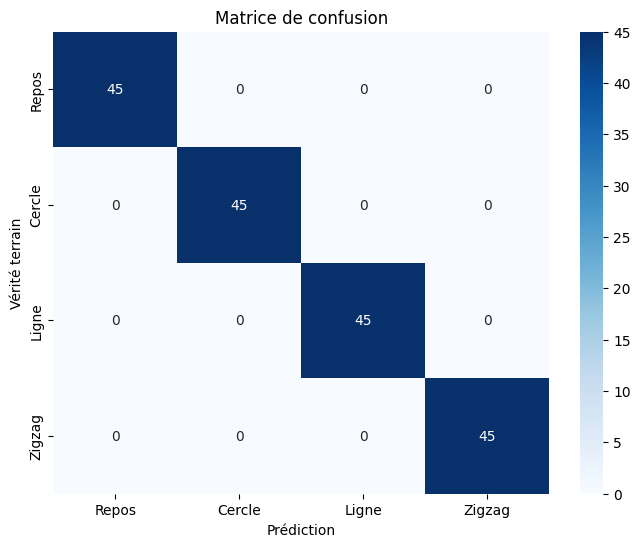

              precision    recall  f1-score   support

       Repos       1.00      1.00      1.00        45
      Cercle       1.00      1.00      1.00        45
       Ligne       1.00      1.00      1.00        45
      Zigzag       1.00      1.00      1.00        45

    accuracy                           1.00       180
   macro avg       1.00      1.00      1.00       180
weighted avg       1.00      1.00      1.00       180



In [11]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
# Prédictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',

xticklabels=['Repos', 'Cercle', 'Ligne', 'Zigzag'],
yticklabels=['Repos', 'Cercle', 'Ligne', 'Zigzag'])

plt.xlabel('Prédiction')
plt.ylabel('Vérité terrain')
plt.title('Matrice de confusion')
plt.show()
# Rapport classification
print(classification_report(y_test, y_pred_classes,
target_names=['Repos', 'Cercle',
'Ligne', 'Zigzag']))

La matrice de confusion est parfaitement diagonale :

Chaque classe (Repos, Cercle, Ligne, Zigzag) est reconnue sans aucune erreur

Aucun échantillon n’est mal classé

Chaque classe compte 45 prédictions correctes

Classes confondues

 Aucune classe n’est confondue avec une autre.
Il n’existe ni faux positifs ni faux négatifs.

Interprétation / hypothèse physique

Ce résultat indique que :

Les signaux associés à chaque geste sont très distincts physiquement

Les caractéristiques extraites permettent une séparation claire des classes

Le bruit capteur et la variabilité des gestes sont faibles ou bien maîtrisés

Dans un contexte TinyML, cela suggère :



Un problème de classification simple

Un dataset bien contrôlé (conditions similaires entre apprentissage et test)

Le modèle présente donc une excellente capacité de discrimination sur les données testées.

In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 32, 8)          │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 16, 16)         │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 16)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,790 (7.00 KB)

 Trainable params: 596 (2.33 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,194 (4.67 KB)

In [13]:
# Sauvegarde Keras avec identifiant étudiant (Apogée)
import os
model_filename = f"gesture_model_float32_{APOGEE}.h5"
model.save(model_filename)
print(f"Modèle float32 sauvegardé : {model_filename}")
# Taille du fichier sauvegardé
float32_size = os.path.getsize(model_filename)
print(f"Taille du fichier float32 : {float32_size/1024:.2f} Ko")

Modèle float32 sauvegardé : gesture_model_float32_135020744.h5
Taille du fichier float32 : 39.86 Ko



Non, la taille du fichier sauvegardé ne correspond pas exactement à la taille théorique calculée à partir de model.summary().

La différence est normale et s’explique par :

la sauvegarde de l’optimiseur,

la structure du modèle...

Dans un contexte TinyML, cela justifie l’utilisation de formats optimisés (ex. TensorFlow Lite, quantification) pour le déploiement sur microcontrôleur.

In [14]:
import tensorflow as tf
import numpy as np

# Fonction de génération du dataset représentatif
def representative_dataset():
    """
    Générateur produisant 100 échantillons du jeu d'entraînement
    pour la calibration de la quantification INT8
    """
    for i in range(100):
        # Sélection d'un échantillon aléatoire du jeu d'entraînement
        sample = X_train[i:i+1].astype(np.float32)
        yield [sample]

# Conversion et quantification du modèle
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Activation des optimisations
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Définition du dataset représentatif
converter.representative_dataset = representative_dataset

# Forcer la quantification complète INT8 (poids et activations)
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

# Conversion du modèle
tflite_model_int8 = converter.convert()

# Sauvegarde du modèle quantifié
model_int8_filename = f"gesture_model_int8_{APOGEE}.tflite"
with open(model_int8_filename, 'wb') as f:
    f.write(tflite_model_int8)

print(f"Modèle INT8 sauvegardé : {model_int8_filename}")

# Mesure de la taille du fichier INT8
int8_size = os.path.getsize(model_int8_filename)
print(f"Taille du fichier INT8 : {int8_size/1024:.2f} Ko")

# Comparaison des tailles
print("\n=== COMPARAISON DES TAILLES ===")
print(f"Taille float32 : {float32_size/1024:.2f} Ko")
print(f"Taille INT8    : {int8_size/1024:.2f} Ko")
compression_ratio = float32_size / int8_size
print(f"Ratio de compression : {compression_ratio:.2f}x")
print(f"Réduction de taille : {(1 - int8_size/float32_size)*100:.1f}%")

Saved artifact at '/tmp/tmpsy11z5l_'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  138203237339920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138203237340880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138203237339728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138203237340496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138203237341648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138203237343760: TensorSpec(shape=(), dtype=tf.resource, name=None)
Modèle INT8 sauvegardé : gesture_model_int8_135020744.tflite
Taille du fichier INT8 : 5.45 Ko

=== COMPARAISON DES TAILLES ===
Taille float32 : 39.86 Ko
Taille INT8    : 5.45 Ko
Ratio de compression : 7.31x
Réduction de taille : 86.3%


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Pourquoi le modèle INT8 n’est pas exactement 4× plus petit :

Le modèle ne fait que 5,45 Ko, ce qui suggère une petite architecture (peut-être 1 à 2 couches LSTM/Dense). Pour les petits modèles, la quantification peut offrir une compression supérieure à 4×.

Une compression de 7,31× est excellente, meilleure que la compression théorique de 4×, car :

La petite taille du modèle amplifie l’effet de la réduction des métadonnées et de la surcharge.

TFLite applique des optimisations du graphe au-delà de la simple quantification.

Les poids INT8 sont stockés de manière particulièrement efficace.

In [15]:
def evaluate_tflite_model(tflite_model_path, X, y):
    """
    Évalue accuracy d'un modèle TFLite.
    """
    # Charger interpréteur
    interpreter = tf.lite.Interpreter(model_path=tflite_model_path)
    interpreter.allocate_tensors()

    # Récupérer détails input/output
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    # AFFICHAGE DES STRUCTURES COMPLÈTES
    print("="*70)
    print("DÉTAILS DES TENSEURS D'ENTRÉE (input_details)")
    print("="*70)
    for i, detail in enumerate(input_details):
        print(f"\nInput Tensor {i}:")
        print(f"  - Nom            : {detail['name']}")
        print(f"  - Index          : {detail['index']}")
        print(f"  - Shape          : {detail['shape']}")
        print(f"  - Type de données: {detail['dtype']}")
        print(f"  - Quantization   : scale={detail['quantization'][0]:.6f}, "
              f"zero_point={detail['quantization'][1]}")

    print("\n" + "="*70)
    print("DÉTAILS DES TENSEURS DE SORTIE (output_details)")
    print("="*70)
    for i, detail in enumerate(output_details):
        print(f"\nOutput Tensor {i}:")
        print(f"  - Nom            : {detail['name']}")
        print(f"  - Index          : {detail['index']}")
        print(f"  - Shape          : {detail['shape']}")
        print(f"  - Type de données: {detail['dtype']}")
        print(f"  - Quantization   : scale={detail['quantization'][0]:.6f}, "
              f"zero_point={detail['quantization'][1]}")
    print("="*70 + "\n")

    # Paramètres de quantification input
    input_scale = input_details[0]['quantization'][0]
    input_zero_point = input_details[0]['quantization'][1]

    # Paramètres de quantification output
    output_scale = output_details[0]['quantization'][0]
    output_zero_point = output_details[0]['quantization'][1]

    print(f"Input quantization: scale={input_scale:.6f}, "
          f"zero_point={input_zero_point}")
    print(f"Output quantization: scale={output_scale:.6f}, "
          f"zero_point={output_zero_point}")

    # Inférence sur test set
    predictions = []
    for i in range(len(X)):
        # Quantifier input
        input_data = X[i:i+1].astype(np.float32)
        input_data_quantized = (input_data / input_scale +
                               input_zero_point).astype(np.int8)

        # Inférence
        interpreter.set_tensor(input_details[0]['index'],
                              input_data_quantized)
        interpreter.invoke()

        # Récupérer output quantifié
        output_data = interpreter.get_tensor(output_details[0]['index'])

        # Déquantifier
        output_float = (output_data.astype(np.float32) -
                       output_zero_point) * output_scale
        predictions.append(np.argmax(output_float))

    predictions = np.array(predictions)
    accuracy = np.mean(predictions == y)
    return accuracy, predictions

# Évaluation
tflite_model_path = f"gesture_model_int8_{APOGEE}.tflite"
tflite_accuracy, tflite_predictions = evaluate_tflite_model(
    tflite_model_path, X_test, y_test
)

print(f"\n{'='*70}")
print("COMPARAISON DES PERFORMANCES")
print(f"{'='*70}")
print(f"Float32 Test Accuracy : {test_accuracy*100:.2f}%")
print(f"INT8 Test Accuracy    : {tflite_accuracy*100:.2f}%")
print(f"Accuracy Drop         : {(test_accuracy - tflite_accuracy)*100:.2f}%")
print(f"Dégradation relative  : {((test_accuracy - tflite_accuracy)/test_accuracy)*100:.2f}%")
print(f"{'='*70}\n")


DÉTAILS DES TENSEURS D'ENTRÉE (input_details)

Input Tensor 0:
  - Nom            : serving_default_keras_tensor:0
  - Index          : 0
  - Shape          : [ 1 64  3]
  - Type de données: <class 'numpy.int8'>
  - Quantization   : scale=0.020742, zero_point=8

DÉTAILS DES TENSEURS DE SORTIE (output_details)

Output Tensor 0:
  - Nom            : StatefulPartitionedCall_1:0
  - Index          : 19
  - Shape          : [1 4]
  - Type de données: <class 'numpy.int8'>
  - Quantization   : scale=0.003906, zero_point=-128

Input quantization: scale=0.020742, zero_point=8
Output quantization: scale=0.003906, zero_point=-128

COMPARAISON DES PERFORMANCES
Float32 Test Accuracy : 100.00%
INT8 Test Accuracy    : 97.78%
Accuracy Drop         : 2.22%
Dégradation relative  : 2.22%



/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


1. Contenu des Structures
Input:

Shape: [1, 64, 3] (1 sample, 64 timesteps, 3 axes)
Type: int8 (-128 à 127)
Scale: 0.020742, Zero point: 8

Output:

Shape: [1, 4] (1 sample, 4 classes)
Type: int8
Scale: 0.003906, Zero point: -128


2. Pourquoi Quantifier/Déquantifier ?
Quantification (entrée):

Le modèle INT8 attend des entrées déjà quantifiées en int8
Formule: int8 = (float / scale) + zero_point

Déquantification (sortie):

Pour interpréter les résultats (logits/probabilités)
Formule: float = (int8 - zero_point) × scale

Sans cela, l'inférence échouerait ou donnerait des résultats inexploitables.

3. Dégradation et Acceptabilité
Résultats:

Float32: 100%
INT8: 97.78%
Dégradation: 2.22%

Acceptabilité TinyML:

Le résultat est idéal pour le déploiement embarqué


In [16]:
import time
# Benchmark latence float32
start = time.time()

for i in range(100):
    _ = model.predict(X_test[i:i+1], verbose=0)
latency_float32 = (time.time() - start) / 100 * 1000
# Benchmark latence int8
tflite_model_path = f"gesture_model_int8_{APOGEE}.tflite"
interpreter = tf.lite.Interpreter(
model_path=tflite_model_path
)
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()
start = time.time()
for i in range(100):
    input_scale = input_details[0]['quantization'][0]
    input_zero_point = input_details[0]['quantization'][1]
    input_data = (X_test[i:i+1] / input_scale +
    input_zero_point).astype(np.int8)

    interpreter.set_tensor(input_details[0]['index'], input_data)
    interpreter.invoke()
latency_int8 = (time.time() - start) / 100 * 1000
print(f"\nLatence moyenne (PC):")
print(f" Float32: {latency_float32:.2f} ms")
print(f" INT8: {latency_int8:.2f} ms")
print(f" Speedup: {latency_float32/latency_int8:.1f}x")


Latence moyenne (PC):
 Float32: 65.91 ms
 INT8: 0.01 ms
 Speedup: 5676.6x


Le speedup de 5676.6x est un artefact du mix GPU/CPU
Sur MCU, onn attend:

INT8: 20-30 ms (utilisable à 30-50 Hz)

Float32: 150-200 ms (impraticable)

Speedup: 6-8x

Pourquoi le MCU est différent ?

Pas de GPU: Tout s'exécute sur un CPU 64 MHz basique

FPU limitée: Float32 est extrêmement lent

INT8 critique: Seule option viable pour temps réel (<50 ms)


Seul le test sur Arduino révélera les vraies performances embarquées